# 03 · 법선(외향) 확인 & 레이더 기준 Occlusion 시각화

PO 시뮬 전 검증: **법선 벡터가 바깥을 향하는가** → **레이더 기하** → **가시성(cosθ>0)** → **Occlusion(레이캐스팅)**.
`po_sim.mesh` / `physics` / `occlusion` 모듈을 그대로 사용합니다.


In [1]:
%matplotlib inline
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# make the package importable whether run from examples/ or po_mdoppler/
cwd = os.getcwd()
PKG = cwd if os.path.isdir(os.path.join(cwd, "po_sim")) else os.path.dirname(cwd)
if PKG not in sys.path:
    sys.path.insert(0, PKG)
print("package root:", PKG)
from configs.default import (SimConfig, MESH_DIR, DATA_BASE,
    BODY_MAT, BLADE_MATS, BLADE_MAT_KEYS, BLADE_OFFSETS, BLADE_DIRS)
from po_sim import mesh, physics, occlusion, kinematics

cfg = SimConfig(); dm = mesh.DroneMesh.load(MESH_DIR)

def set_equal(ax, V):
    mn, mx = V.min(0), V.max(0); c = (mn+mx)/2; r = (mx-mn).max()/2 + 1e-9
    ax.set_xlim(c[0]-r, c[0]+r); ax.set_ylim(c[1]-r, c[1]+r); ax.set_zlim(c[2]-r, c[2]+r)

print("mesh:", dm.total_tris, "tris | MESH_DIR:", MESH_DIR)

package root: /workspace/sionna_sim/po_mdoppler


mesh: 31446 tris | MESH_DIR: /workspace/sionna_sim/po_mdoppler/Mesh


## 1) 법선 외향 확인
각 패싯 법선과 (패싯중심 − 기체중심) 의 내적 > 0 이면 바깥 방향. Mesh/ 는 보정본이라 대부분 외향이어야 합니다.

outward-facing: 99.82% (30111/30166)


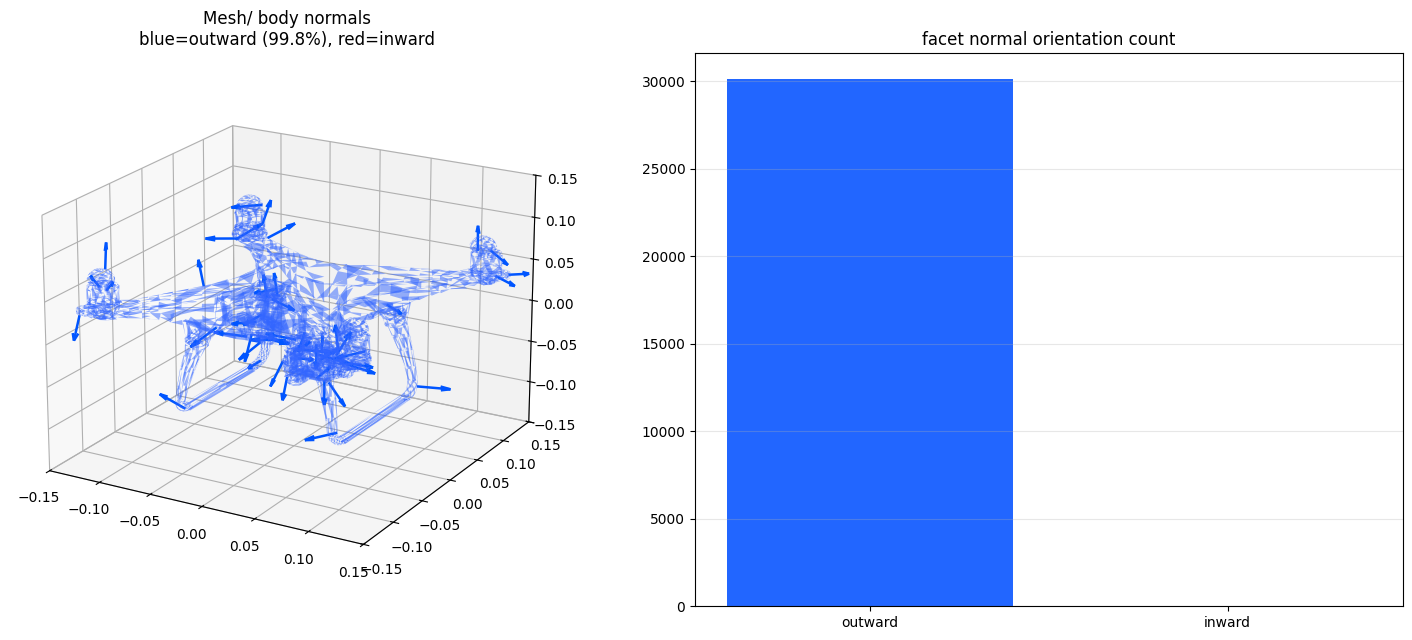

BEFORE (Phantom4_Mesh_tri): 58.07% outward  ->  Mesh/ (fixed): 99.82% outward


In [2]:
centers, normals, areas = dm.body_facets(np.eye(3), np.zeros(3))   # identity = local
centroid = dm.body_v.mean(axis=0)
dot = np.sum(normals * (centers - centroid), axis=1)
pct_out = 100 * (dot > 0).mean()
print("outward-facing: %.2f%% (%d/%d)" % (pct_out, (dot > 0).sum(), len(dot)))

fig = plt.figure(figsize=(15, 6.5))
ax = fig.add_subplot(1, 2, 1, projection="3d")
sub = slice(None, None, 3)
polys = dm.body_v[dm.body_f][sub]; d3 = dot[sub]
fc = np.where((d3 > 0)[:, None], [0.2, 0.4, 1.0, 0.5], [1.0, 0.15, 0.15, 0.9])
pc = Poly3DCollection(polys, linewidths=0); pc.set_facecolor(fc); ax.add_collection3d(pc)
for i in range(0, len(centers), 600):
    c = centers[i]; n = normals[i]*0.03
    ax.quiver(c[0], c[1], c[2], n[0], n[1], n[2],
              color=("#0055FF" if dot[i] > 0 else "#FF0000"), arrow_length_ratio=0.3, linewidth=1.8)
lim = 0.15; ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-lim, lim)
ax.set_title("Mesh/ body normals\nblue=outward (%.1f%%), red=inward" % pct_out); ax.view_init(elev=20, azim=-60)
ax2 = fig.add_subplot(1, 2, 2)
ax2.bar(["outward", "inward"], [(dot > 0).sum(), (dot < 0).sum()], color=["#2266FF", "#FF2222"])
ax2.set_title("facet normal orientation count"); ax2.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

# before/after vs the original triangulated (un-corrected) mesh, if present
tri_dir = os.path.join(os.path.dirname(PKG), "Phantom4_Mesh_tri")
if os.path.isdir(tri_dir):
    from po_sim.mesh import load_ply, facet_geometry
    tv, tf = load_ply(os.path.join(tri_dir, "drone_body.ply"))
    tc, tn, ta = facet_geometry(tv[tf[:, 0]], tv[tf[:, 1]], tv[tf[:, 2]])
    tdot = np.sum(tn * (tc - tv.mean(0)), axis=1)
    print("BEFORE (Phantom4_Mesh_tri): %.2f%% outward  ->  Mesh/ (fixed): %.2f%% outward"
          % (100*(tdot > 0).mean(), pct_out))
else:
    print("(original tri mesh not found for before/after - fine)")

## 2) 레이더 기하
고정 지상국(monostatic). 비행 중심 기준 수평 뒤 60 m, 아래 20 m.

t=45.7s | drone [31.3 -2.5  8.1] | radar [ 32.2 -60.6  -9.5] | slant 60.7 m | elevation 16.9 deg


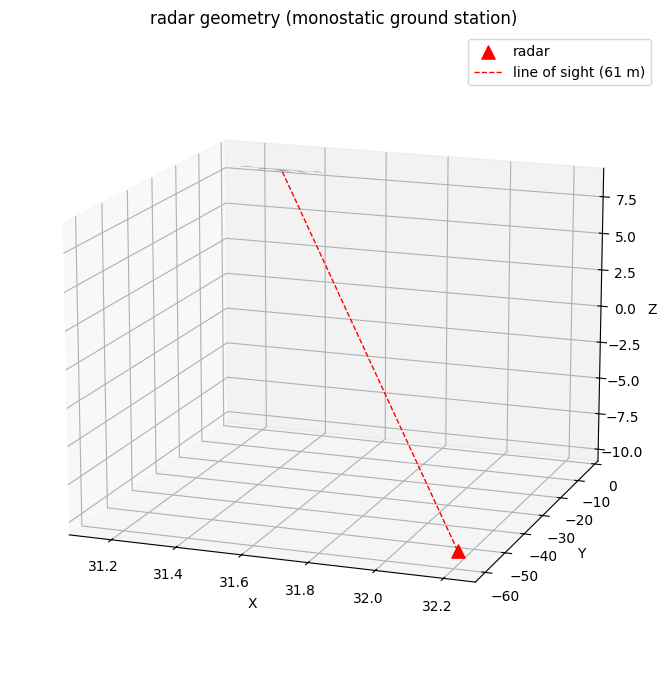

In [3]:
flight = kinematics.load_flight(os.path.join(DATA_BASE, "grade_2"), cfg)
radar_pos = kinematics.radar_position(flight.flight_center, cfg)
starts = kinematics.window_starts(flight, cfg)
T = starts[len(starts)//2]
p = flight.pos_interp(T); R = flight.rot_interp(T).as_matrix(); a = flight.blade_angles_interp(T)
slant = np.linalg.norm(p - radar_pos)
elev_ang = np.degrees(np.arcsin((p[2] - radar_pos[2]) / slant))
azim_view = np.degrees(np.arctan2(radar_pos[1] - p[1], radar_pos[0] - p[0]))
print("t=%.1fs | drone %s | radar %s | slant %.1f m | elevation %.1f deg"
      % (T, np.round(p, 1), np.round(radar_pos, 1), slant, elev_ang))

fig = plt.figure(figsize=(9, 7)); ax = fig.add_subplot(111, projection="3d")
bw = dm.body_vertices_world(R, p)
ax.add_collection3d(Poly3DCollection(bw[dm.body_f[::4]], alpha=0.4, facecolor="gray", edgecolor="none"))
ax.scatter(*radar_pos, c="red", s=90, marker="^", label="radar")
ax.plot([radar_pos[0], p[0]], [radar_pos[1], p[1]], [radar_pos[2], p[2]], "r--", lw=1,
        label="line of sight (%.0f m)" % slant)
ax.set_title("radar geometry (monostatic ground station)"); ax.legend(); ax.view_init(elev=15, azim=-70)
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z"); plt.tight_layout(); plt.show()

## 3) 가시성 (cosθ > 0) — `physics.visible_facets`
법선이 레이더를 향하는 패싯만 1차 후보.

normal-visible body facets: 15145 / 30166 (50.2%)


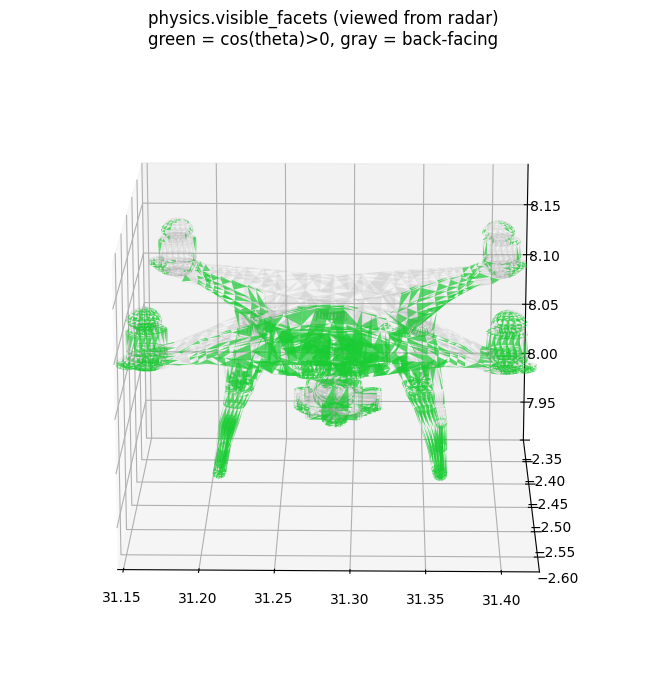

In [4]:
centers, normals, areas = dm.body_facets(R, p)
visible, dist, cos_t = physics.visible_facets(centers, normals, radar_pos)
print("normal-visible body facets: %d / %d (%.1f%%)" % (visible.sum(), len(visible), 100*visible.mean()))

fig = plt.figure(figsize=(8, 7)); ax = fig.add_subplot(111, projection="3d")
bw = dm.body_vertices_world(R, p); polys = bw[dm.body_f]
fc = np.where(visible[:, None], [0.1, 0.8, 0.2, 0.7], [0.6, 0.6, 0.6, 0.15])
pc = Poly3DCollection(polys[::2], linewidths=0); pc.set_facecolor(fc[::2]); ax.add_collection3d(pc)
set_equal(ax, bw); ax.view_init(elev=elev_ang, azim=azim_view)
ax.set_title("physics.visible_facets (viewed from radar)\ngreen = cos(theta)>0, gray = back-facing")
plt.tight_layout(); plt.show()

## 4) Occlusion (레이캐스팅) — `occlusion` 모듈
- **body 자기차폐**: 레이더→패싯 첫 히트가 자기 자신이어야 보임 (`self_occlusion_mask`)
- **blade 몸체차폐**: body 가 blade 를 가리는지 (`body_block_mask`)

body : back-facing 15021 | self-occluded 10779 | visible 4366
blades: back-facing 963 | body-occluded 75 | visible 242


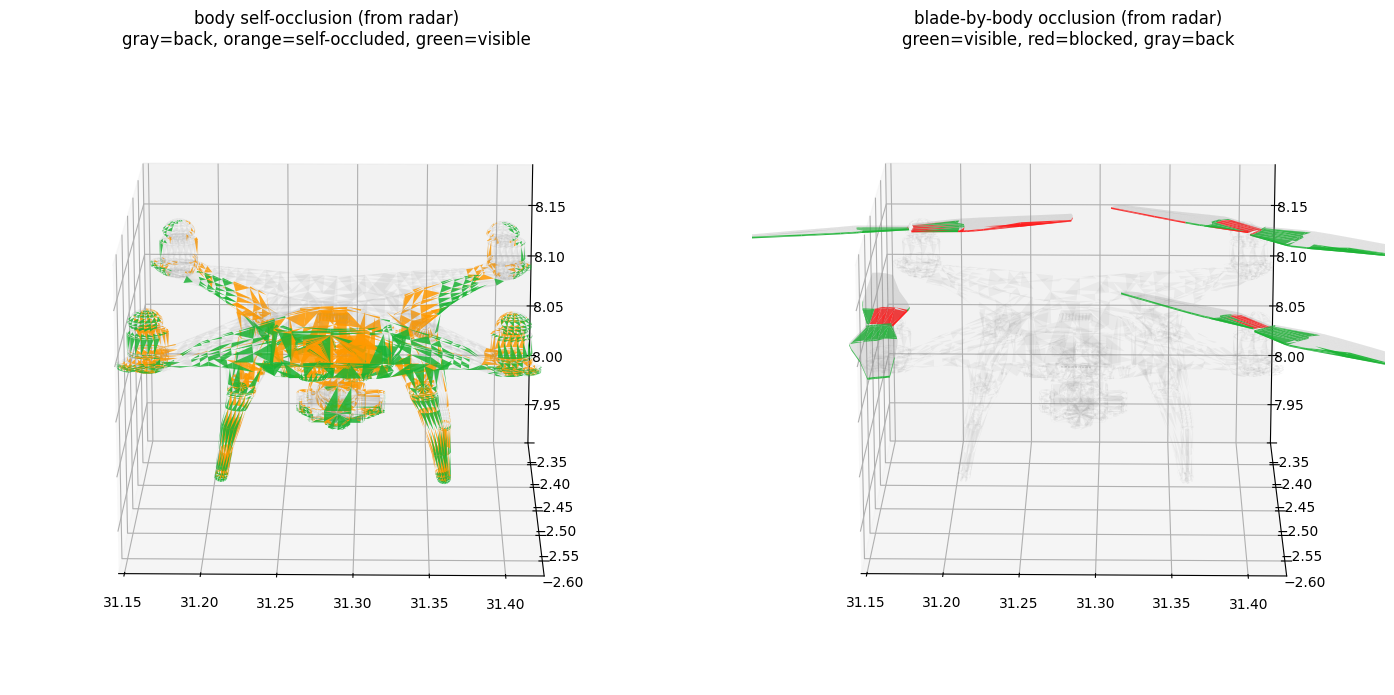

In [5]:
bvh = occlusion.build_body_bvh(dm, R, p)

# --- body: back-facing / self-occluded / visible ---
cat = np.zeros(len(dm.body_f), int)
vis_idx = np.where(visible)[0]
cat[vis_idx] = 1
not_occ = occlusion.self_occlusion_mask(bvh, centers, vis_idx, radar_pos)
cat[vis_idx[not_occ]] = 2
print("body : back-facing %d | self-occluded %d | visible %d"
      % ((cat == 0).sum(), (cat == 1).sum(), (cat == 2).sum()))

fig = plt.figure(figsize=(15, 7))
ax = fig.add_subplot(1, 2, 1, projection="3d")
bw = dm.body_vertices_world(R, p); polys = bw[dm.body_f]
cmap = {0: [0.6, 0.6, 0.6, 0.12], 1: [1.0, 0.6, 0.0, 0.85], 2: [0.1, 0.7, 0.2, 0.85]}
fc = np.array([cmap[c] for c in cat])
pc = Poly3DCollection(polys[::2], linewidths=0); pc.set_facecolor(fc[::2]); ax.add_collection3d(pc)
set_equal(ax, bw); ax.view_init(elev=elev_ang, azim=azim_view)
ax.set_title("body self-occlusion (from radar)\ngray=back, orange=self-occluded, green=visible")

# --- blades: visible / body-occluded / back-facing ---
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.add_collection3d(Poly3DCollection(polys[::4], linewidths=0, facecolor=[0.5, 0.5, 0.5, 0.08]))
COL = {"vis": [0.1, 0.7, 0.2, 0.9], "occ": [1.0, 0.1, 0.1, 0.9], "back": [0.6, 0.6, 0.6, 0.15]}
nb_vis = nb_occ = nb_back = 0
for b in range(dm.n_blades):
    ang = a[b] * BLADE_DIRS[b]
    cb, nbn, ab = dm.blade_facets(b, ang, R, p, BLADE_OFFSETS[b])
    visb, distb, cosb = physics.visible_facets(cb, nbn, radar_pos)
    vw = dm.blade_vertices_world(b, ang, R, p, BLADE_OFFSETS[b]); bpolys = vw[dm.blade_f_list[b]]
    fcb = np.tile(COL["back"], (len(bpolys), 1))
    vb_idx = np.where(visb)[0]
    if len(vb_idx):
        keep = occlusion.body_block_mask(bvh, cb, vb_idx, radar_pos)
        fcb[vb_idx] = COL["occ"]
        fcb[vb_idx[keep]] = COL["vis"]
        nb_vis += int(keep.sum()); nb_occ += int((~keep).sum())
    nb_back += int((~visb).sum())
    ax2.add_collection3d(Poly3DCollection(bpolys, linewidths=0, facecolor=fcb))
print("blades: back-facing %d | body-occluded %d | visible %d" % (nb_back, nb_occ, nb_vis))
set_equal(ax2, bw); ax2.view_init(elev=elev_ang, azim=azim_view)
ax2.set_title("blade-by-body occlusion (from radar)\ngreen=visible, red=blocked, gray=back")
plt.tight_layout(); plt.show()

---
**요약** — 이 3-way 분류가 `engine.compute_pulse_decomposed` 의 `body_none/body_occ`,
`blade_none_*/blade_occ_*` 저장으로 이어집니다. occlusion 은 재질과 무관하므로 한 번 계산해
모든 블레이드 재질에 재사용됩니다.